# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/4Derivatives_fig1.png" alt="MAE vs. Spacing Between Points" width=100%>


<div align="center"> Figure 1: Plot of Mean Absolute Error (MAE) vs. Spacing Between Points </div>

### Report discussion

The log-log plot of the error against the point spacing clearly shows how fast the error shrinks for each method. As the step size gets smaller, the central difference error drops with a slope of 2, proving that it has second-order accuracy, $O(h^2)$. In contrast, the forward and backward differences show a slope of 1, meaning they only have first-order accuracy, $O(h)$. These accuracy levels come directly from how the methods are built using the Taylor series. For the one-sided differences, the math leaves behind a leftover error tied to the second derivative, limiting them to $O(h)$. The central difference combines the forward and backward steps, and this symmetry perfectly cancels out that larger error term, leaving a much smaller error tied to the third derivative and giving it $O(h^2)$ precision. Because it is much more accurate, the central method is the best choice for calculating derivatives at the middle points of a dataset. However, one-sided differences are still needed at the very edges of a graph where neighboring points are missing (this is observed in the code as we have essentially removed the first and last terms since they don't have $x_{i-1}$ and $x_{i+1}$, respectively).

### Other comments
- I have no other comments (I cannot yap as I did not have a lot of time for this experiment (I had to do other stuff))

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

The derivative is:
$$ f'(x) = 5 x \cos (x+\frac{\pi}{4}) + 5 \sin(x+\frac{\pi}{4}) $$

Say you start with 257 points from 0 to $4\pi$ 

C:\Users\Christan Jake\AppData\Local\Temp\ipykernel_23252\43196667.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


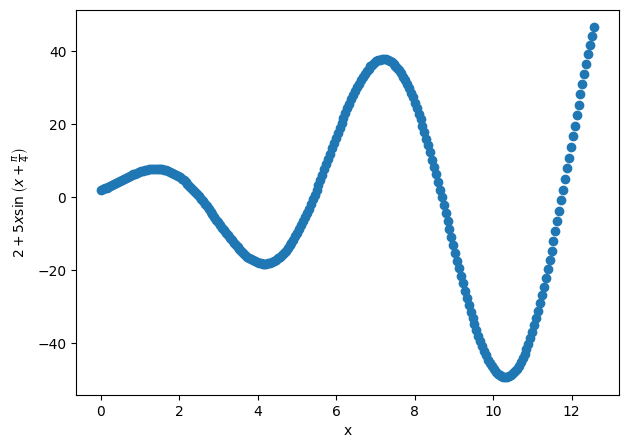

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)

x = np.linspace(0, 4*np.pi, 257)

fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [3]:
# PART A
f_prime = lambda x: (5*x*np.cos(1*x+np.pi/4)) + (5*np.sin(1*x+np.pi/4))

def forward_deriv(f,x):
    h = x[1] - x[0]
    fd_x = x[:-1]                           #removes last term and creates a new list
    fd_y = (f(x[1:]) - f(fd_x)) / h         #f(x[1:]) removes first term and f(fd_x) = f(x[:-1]) removes last term so we match f(x1) and f(x0), or, generally, f(x_i + 1) with f(x_i)
    return fd_x, fd_y
    
def backward_deriv(f,x):
    h = x[1] - x[0]
    bd_x = x[1:]                            #here, we remove the first term
    bd_y = (f(bd_x) - f(x[:-1])) / h        #we match f(x1) with f(x0). this is essentially similar to the first one, but instead of starting with the first x term, we start with the last x term, meaning that the first x term will have no partner and is thus removed
    return bd_x, bd_y

def central_deriv(f,x):
    h = x[1] - x[0]
    cd_x = x[1:-1]
    cd_y = (f(x[2:]) - f(x[:-2])) / (2*h)   #f(x2) - f(x0) = f(x_i+1) - f(x_i-1)
    return cd_x, cd_y

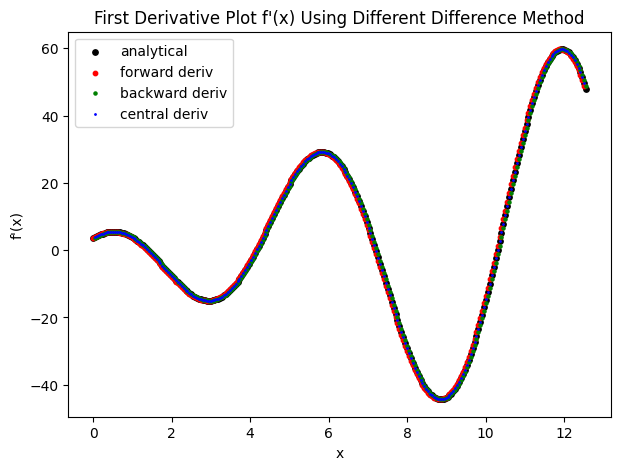

In [5]:
# PART B
fig, ax = plt.subplots(figsize = (7,5))

fd_x, fd_y = forward_deriv(f_0, x)
bd_x, bd_y = backward_deriv(f_0, x)
cd_x, cd_y = central_deriv(f_0, x)

ax.scatter(x, f_prime(x), s=15, c="black", label="analytical")
ax.scatter(fd_x, fd_y, s=10, c="red", label="forward deriv")
ax.scatter(bd_x, bd_y, s=5, c="green", label="backward deriv")
ax.scatter(cd_x, cd_y, s=1, c="blue", label="central deriv")

ax.set_title("First Derivative Plot f'(x) Using Different Difference Method")
ax.set_ylabel(r"f'(x)")
ax.set_xlabel("x")

plt.legend()
plt.show()

In [6]:
# PART C: Mean Absolute Error (MAE) Calculation (for 256 points)
error_fd = np.mean(np.abs(fd_y - f_prime(fd_x)))
error_bd = np.mean(np.abs(bd_y - f_prime(bd_x)))
error_cd = np.mean(np.abs(cd_y - f_prime(cd_x)))

print(f"Forward Error: {error_fd}")
print(f"Backward Error: {error_bd}")
print(f"Central Error: {error_cd}")

Forward Error: 0.499554301485504
Backward Error: 0.5005317898124961
Central Error: 0.009652197768682558


In [8]:
# PART D: Same as C but for arbitrary points (in this context: 64/128/256/512/1024 points)
def MAE_calc(step):
    x_new = np.linspace(0, 4 * np.pi, step + 1)
    h = x_new[1] - x_new[0]

    fd_x, fd_y = forward_deriv(f_0, x_new)
    bd_x, bd_y = backward_deriv(f_0, x_new)
    cd_x, cd_y = central_deriv(f_0, x_new)
    
    err_fd = np.mean(np.abs(fd_y - f_prime(fd_x)))
    err_bd = np.mean(np.abs(bd_y - f_prime(bd_x)))
    err_cd = np.mean(np.abs(cd_y - f_prime(cd_x)))
    
    return h, float(err_fd), float(err_bd), float(err_cd)       #h is needed for part E, not necessarily for D

print("FORMAT: n points: [forward diff error, backward diff error, central diff error]")
print("64 points: ", list(MAE_calc(64))[1:])
print("128 points: ", list(MAE_calc(128))[1:])
print("256 points: ", list(MAE_calc(256))[1:])
print("512 points: ", list(MAE_calc(512))[1:])
print("1024 points: ", list(MAE_calc(1024))[1:])
    

FORMAT: n points: [forward diff error, backward diff error, central diff error]
64 points:  [1.9923455730807487, 2.0042578253649435, 0.15328436823365538]
128 points:  [0.997664513636557, 1.0017101488022746, 0.03852587462907194]
256 points:  [0.499554301485504, 0.5005317898124961, 0.009652197768682558]
512 points:  [0.24992804436656157, 0.2501680318952602, 0.0024151495736079408]
1024 points:  [0.12499594287813004, 0.12505637456848195, 0.0006040180408414882]


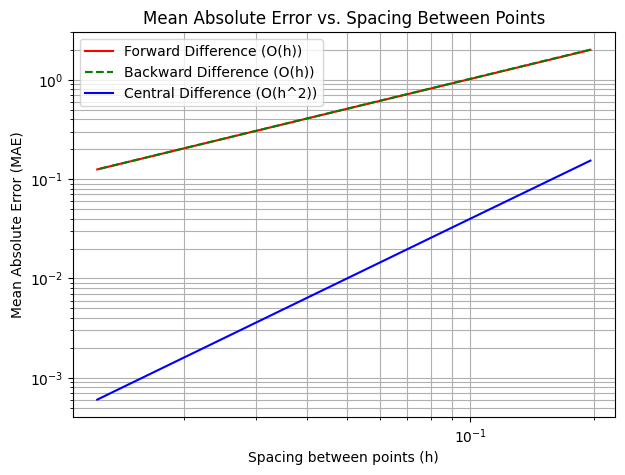

<module 'matplotlib.pyplot' from 'C:\\Users\\Christan Jake\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [9]:
#PART E: plot of the MAE vs the spacing between points
step_counts = [64, 128, 256, 512, 1024]

h_values = []
error_forward = []
error_backward = []
error_central = []

for i in step_counts:
    h, e_fd, e_bd, e_cd = MAE_calc(i)
    h_values.append(h)
    error_forward.append(e_fd)
    error_backward.append(e_bd)
    error_central.append(e_cd)

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(h_values, error_forward, label="Forward Difference (O(h))", color="red")
ax.loglog(h_values, error_backward, linestyle="--", label="Backward Difference (O(h))", color="green")
ax.loglog(h_values, error_central, label="Central Difference (O(h^2))", color="blue")

ax.set_title("Mean Absolute Error vs. Spacing Between Points")
ax.set_xlabel("Spacing between points (h)")
ax.set_ylabel("Mean Absolute Error (MAE)")
ax.grid(True, which="both")
ax.legend()

plt.show()
plt

#### Problem 1 code summary

My code for this problem implements forward, backward, and central difference algorithms to approximate the first derivative of a given function across dynamically generated grid spacings (64 to 1024). The various slicing methods were expounded within the inline comments in the code. The implementation evaluated the truncation errors of each method by calculating the mean absolute error (MAE) relative to the analytically derived function at varying resolutions (i.e., step size). Finally, the code generates a log-log plot to visually verify the theoretical convergence rates which demonstrates the $O(h^1)$ accuracy of the one-sided differences and the superior $O(h^2)$ precision of the central method. We can observe this in the results in Parts D and E.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [12]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
